# FAIRNESS EVALUATION

=== Distribusi Populasi vs Audit — Gender ===
       proporsi_populasi  proporsi_diaudit  selisih
jkpst                                              
P                 0.5362            0.5437   0.0075
L                 0.4638            0.4563  -0.0075

=== Base rate fraud (label asli) per gender ===
jkpst
L    0.5007
P    0.5007
Name: true_label, dtype: float64

=== Precision audit per gender (dari yang diaudit) ===
jkpst
L    0.9704
P    0.9665
Name: true_label, dtype: float64
=== Distribusi Populasi vs Audit — Age Group ===
           proporsi_populasi  proporsi_diaudit  selisih
age_group                                              
40-59                 0.2987            0.3033   0.0046
18-39                 0.2584            0.2621   0.0037
0-17                  0.2505            0.2562   0.0057
60+                   0.1924            0.1783  -0.0141

=== Base rate fraud per age group ===
age_group
0-17     0.4985
18-39    0.4986
40-59    0.5027
60+      0.5034
Name: true_label,

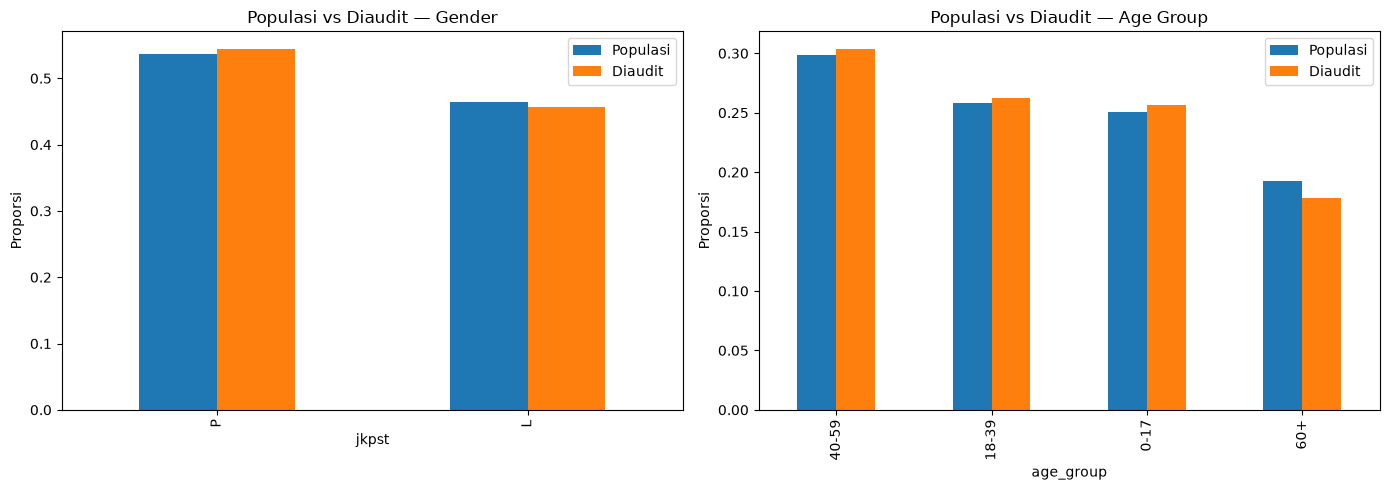

=== Audit rate per kombinasi gender x age group ===
age_group    0-17   18-39   40-59     60+
jkpst                                    
L          0.0498  0.0509  0.0501  0.0456
P          0.0530  0.0506  0.0512  0.0472


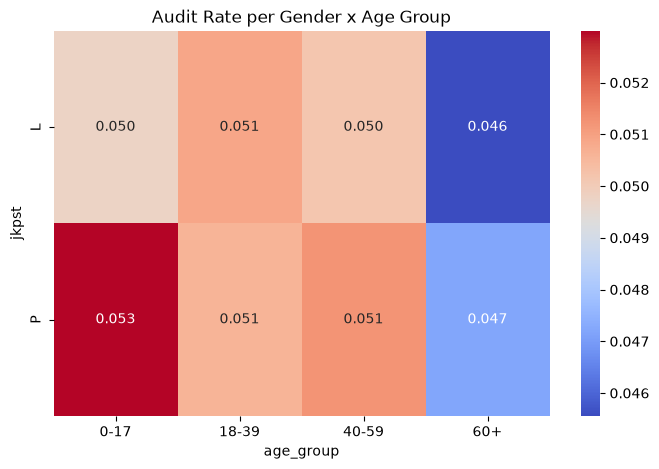

In [2]:
# Import, Config, and Load
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = "/Users/annya/DAC/Dataset/Processed"

y_full = np.load("/Users/annya/DAC/results/predictions/y_full.npy")
final_oof_score = np.load("/Users/annya/DAC/results/predictions/weighted_rank_oof.npy")
train_raw = pd.read_csv("/Users/annya/DAC/Dataset/RawDataset/train.csv")

def bucket_age(umur):
    if umur <= 17: return '0-17'
    elif umur <= 39: return '18-39'
    elif umur <= 59: return '40-59'
    else: return '60+'

train_raw['age_group'] = train_raw['umur'].apply(bucket_age)

train_ids_full = pd.read_csv(f"{DATA_DIR}/train_ids.csv").squeeze()  
val_ids = pd.read_csv(f"{DATA_DIR}/val_ids.csv").squeeze() if False else None  

full_ids = train_ids_full

fairness_df = train_raw.set_index('claim_id').loc[full_ids].reset_index()
fairness_df['model_score'] = final_oof_score
fairness_df['true_label'] = y_full

# Marked the one that getting audited
# ============================================================
n = len(fairness_df)
k_5pct = int(np.floor(0.05 * n))

order = np.argsort(-fairness_df['model_score'].values)
audited_mask = np.zeros(n, dtype=bool)
audited_mask[order[:k_5pct]] = True

fairness_df['audited'] = audited_mask

# Analyzed Gender
# ============================================================
print("=== Distribusi Populasi vs Audit — Gender ===")
pop_gender = fairness_df['jkpst'].value_counts(normalize=True)
audit_gender = fairness_df[fairness_df['audited']]['jkpst'].value_counts(normalize=True)

gender_compare = pd.DataFrame({
    'proporsi_populasi': pop_gender,
    'proporsi_diaudit': audit_gender
})
gender_compare['selisih'] = gender_compare['proporsi_diaudit'] - gender_compare['proporsi_populasi']
print(gender_compare.round(4))

print("\n=== Base rate fraud (label asli) per gender ===")
print(fairness_df.groupby('jkpst')['true_label'].mean().round(4))

print("\n=== Precision audit per gender (dari yang diaudit) ===")
print(fairness_df[fairness_df['audited']].groupby('jkpst')['true_label'].mean().round(4))

# Analyzed Age Group
# ============================================================
print("=== Distribusi Populasi vs Audit — Age Group ===")
pop_age = fairness_df['age_group'].value_counts(normalize=True)
audit_age = fairness_df[fairness_df['audited']]['age_group'].value_counts(normalize=True)

age_compare = pd.DataFrame({
    'proporsi_populasi': pop_age,
    'proporsi_diaudit': audit_age
})
age_compare['selisih'] = age_compare['proporsi_diaudit'] - age_compare['proporsi_populasi']
print(age_compare.round(4))

print("\n=== Base rate fraud per age group ===")
print(fairness_df.groupby('age_group')['true_label'].mean().round(4))

print("\n=== Precision audit per age group ===")
print(fairness_df[fairness_df['audited']].groupby('age_group')['true_label'].mean().round(4))

# Analyzed Age Group
# ============================================================
print("=== Distribusi Populasi vs Audit — Age Group ===")
pop_age = fairness_df['age_group'].value_counts(normalize=True)
audit_age = fairness_df[fairness_df['audited']]['age_group'].value_counts(normalize=True)

age_compare = pd.DataFrame({
    'proporsi_populasi': pop_age,
    'proporsi_diaudit': audit_age
})
age_compare['selisih'] = age_compare['proporsi_diaudit'] - age_compare['proporsi_populasi']
print(age_compare.round(4))

print("\n=== Base rate fraud per age group ===")
print(fairness_df.groupby('age_group')['true_label'].mean().round(4))

print("\n=== Precision audit per age group ===")
print(fairness_df[fairness_df['audited']].groupby('age_group')['true_label'].mean().round(4))

#Visualization of Disparities
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

gender_compare[['proporsi_populasi', 'proporsi_diaudit']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Populasi vs Diaudit — Gender')
axes[0].set_ylabel('Proporsi')
axes[0].legend(['Populasi', 'Diaudit'])

age_compare[['proporsi_populasi', 'proporsi_diaudit']].plot(kind='bar', ax=axes[1])
axes[1].set_title('Populasi vs Diaudit — Age Group')
axes[1].set_ylabel('Proporsi')
axes[1].legend(['Populasi', 'Diaudit'])

plt.tight_layout()
plt.savefig("/Users/annya/DAC/outputs/figures/fairness_disparity.png", dpi=150)
plt.show()

# Gender × Age Group Combine
# ============================================================
print("=== Audit rate per kombinasi gender x age group ===")
audit_rate_subgroup = fairness_df.groupby(['jkpst', 'age_group'])['audited'].mean().unstack()
print(audit_rate_subgroup.round(4))

plt.figure(figsize=(8, 5))
sns.heatmap(audit_rate_subgroup, annot=True, fmt='.3f', cmap='coolwarm')
plt.title('Audit Rate per Gender x Age Group')
plt.savefig("/Users/annya/DAC/outputs/figures/fairness_heatmap.png", dpi=150)
plt.show()

#Done
# ============================================================
gender_compare.to_csv("/Users/annya/DAC/results/fairness/gender_comparison.csv")
age_compare.to_csv("/Users/annya/DAC/results/fairness/age_comparison.csv")
audit_rate_subgroup.to_csv("/Users/annya/DAC/results/fairness/subgroup_audit_rate.csv")